# Importación de librerías

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL

!pip install "transformers==4.44.0" -q
from transformers import TFViTModel, ViTConfig

import glob
import cv2
!pip install split-folders
import splitfolders
import shutil

import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Sequential
from tensorflow.keras.models import Model

from sklearn import svm
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import  accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

Montar el drive y cargar el dataset.

In [ ]:
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\EVENODD'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\ODD'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\EVEN'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\GROUP09'
root_dir = r'C:\Users\TU_RUTA_AL_DATASET\KAGGLE'

train_folder = os.path.join(root_dir, "train")
val_folder   = os.path.join(root_dir, "val")
test_folder  = os.path.join(root_dir, "test")

# Parámetros
batch_size= 16
img_height= 224
img_width= 224
dropout_rate = 0.5
epochs= 50
num_classes  = 6

train_ds = tf.keras.utils.image_dataset_from_directory(
  train_folder,
  seed = 123,
  image_size = (img_height, img_width),
  batch_size = batch_size,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  val_folder,
  seed=123,
  image_size=(img_height, img_width),
  batch_size = batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_folder,
    seed = 123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(class_names)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Found 6460 files belonging to 6 classes.
Found 1382 files belonging to 6 classes.
Found 1390 files belonging to 6 classes.
['cups', 'forks', 'glasses', 'knives', 'plates', 'spoons']


Creamos el training, validation y test dataset

Imprimir 9 imágenes del dataset

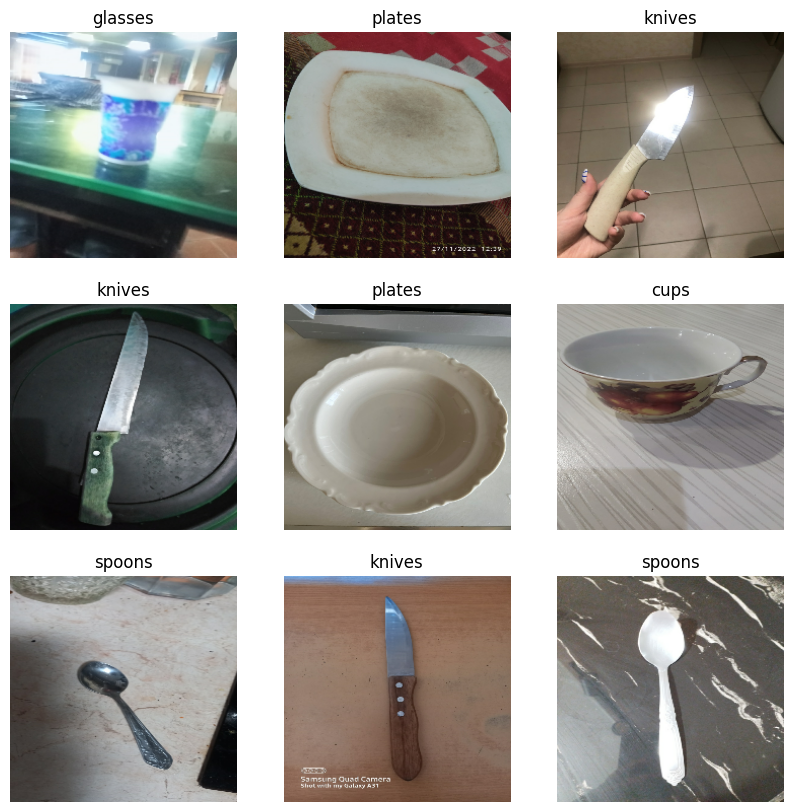

In [12]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

Arquitectura

In [13]:
import tensorflow as tf

class SparseF1Score(tf.keras.metrics.F1Score):
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32) # tipo int32
        y_true = tf.reshape(y_true, [-1]) # aplanar a 1D
        num_classes = tf.shape(y_pred)[-1] # número de clases desde y_pred
        y_true_one_hot = tf.one_hot(y_true, depth=num_classes) # convertir a One-Hot
        return super().update_state(y_true_one_hot, y_pred, sample_weight) # pasar los datos al F1Score original

In [ ]:
class ViTBackbone(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.vit = TFViTModel.from_pretrained(
            "google/vit-base-patch16-224-in21k",
            output_attentions=False,
            output_hidden_states=False,
        )
        print("Total params ViT:", self.vit.num_parameters())

    def call(self, x, training=False):
        # x ya viene como tensor real en call(), no KerasTensor
        x_t = tf.transpose(x, perm=[0, 3, 1, 2])  # (B, H, W, 3) → (B, 3, H, W)
        outputs = self.vit(pixel_values=x_t, training=training)
        return outputs.last_hidden_state[:, 0, :]   # [CLS] token → (B, 768)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from transformers import TFViTModel

class ViTClassifier:
  IMAGE_SIZE = 224

  def __init__(self, num_classes: int, dropout_rate: float = dropout_rate):
    self.num_classes = num_classes
    self.dropout_rate = dropout_rate
    self.model = self._build_model()
    self.history = None

  def _build_model(self):
    pixel_input = tf.keras.Input(
        shape=(self.IMAGE_SIZE, self.IMAGE_SIZE, 3),
        name="pixel_input"
    )

    # preprocesado
    x = tf.keras.layers.Rescaling(1.0 / 255)(pixel_input)

    # data Augmentation
    x = tf.keras.layers.RandomFlip("horizontal")(x)
    x = tf.keras.layers.RandomRotation(0.1)(x)
    x = tf.keras.layers.RandomZoom(0.1)(x)
    x = tf.keras.layers.RandomContrast(0.1)(x)

    # normalización estándar ViT [-1, 1]
    mean = tf.constant([0.5, 0.5, 0.5], dtype=tf.float32)
    std  = tf.constant([0.5, 0.5, 0.5], dtype=tf.float32)
    x = tf.keras.layers.Lambda(lambda img: (img - mean) / std)(x)

    # backbone ViT-B/16
    x = ViTBackbone(name="vit_backbone")(x, training=True)

    # cabeza de clasificación
    x = tf.keras.layers.LayerNormalization()(x)

    x = tf.keras.layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = tf.keras.layers.Activation("gelu")(x)
    x = tf.keras.layers.Dropout(self.dropout_rate)(x)

    x = tf.keras.layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = tf.keras.layers.Activation("gelu")(x)
    x = tf.keras.layers.Dropout(self.dropout_rate * 0.5)(x)

    output = tf.keras.layers.Dense(self.num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=pixel_input, outputs=output, name="ViT_B16")
    model.summary()
    return model

  def compile(self, learning_rate: float = 2e-5, weight_decay: float = 1e-4):
    steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
    warmup_steps = steps_per_epoch * 5
    total_steps  = steps_per_epoch * epochs

    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=learning_rate,
        decay_steps=total_steps - warmup_steps,
        alpha=1e-6,
        warmup_target=learning_rate,
        warmup_steps=warmup_steps,
    )
    self.model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=lr_schedule,
            weight_decay=weight_decay,
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy", SparseF1Score(average="weighted", name="f1_score")],
    )


  def fit_model(self):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_f1_score",
            patience=7,
            restore_best_weights=True,
            mode="max",
        ),
        tf.keras.callbacks.ModelCheckpoint(
            "best_vit_model.keras",
            monitor="val_f1_score",
            save_best_only=True,
            mode="max",
        ),
    ]

    self.history = self.model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
    )

  def plots(self):
    acc= self.history.history["accuracy"]
    val_acc  = self.history.history["val_accuracy"]
    loss = self.history.history["loss"]
    val_loss = self.history.history["val_loss"]
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc,     label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Val Accuracy")
    plt.legend(loc="lower right")
    plt.title("Accuracy")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss,     label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Val Loss")
    plt.legend(loc="upper right")
    plt.title("Loss")
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=120)
    plt.show()

  def get_predictions(self, dataset):
    y_true, y_pred, images_list = [], [], []
    for images, labels in dataset:
        preds = self.model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())
        images_list.extend(images.numpy())
    return np.array(y_true), np.array(y_pred), np.array(images_list)

  def plot_confusion_matrix(self, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=ax,
    )
    ax.set_title("Confusion Matrix (normalized)")
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=120)
    plt.show()

  def plot_misclassified(self, y_true, y_pred, images, n=12):
    wrong_idx = np.where(y_true != y_pred)[0]
    print(f"Total mal clasificadas: {len(wrong_idx)} / {len(y_true)}")

    show = wrong_idx[:n]
    cols = 4
    rows = int(np.ceil(len(show) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    for i, idx in enumerate(show):
        axes[i].imshow(images[idx].astype("uint8"))
        axes[i].set_title(
            f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}",
            color="red", fontsize=10,
        )
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Imágenes mal clasificadas", fontsize=13)
    plt.tight_layout()
    plt.savefig("misclassified.png", dpi=120)
    plt.show()

  def evaluate(self):
    print("\n── Evaluación en Test ──")
    results = self.model.evaluate(test_ds, verbose=1)
    for name, val in zip(self.model.metrics_names, results):
        print(f"  {name}: {val:.4f}")

All PyTorch model weights were used when initializing TFViTModel.

All the weights of TFViTModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.


Model: "ViT_B16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pixel_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vit_backbone (ViTBackbone)      │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 768)            │         1,536 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 528,134 (2.01 MB)

 Trainable params: 528,134 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 1159s 3s/step - accuracy: 0.5872 - f1_score: 0.5906 - loss: 1.2351 - val_accuracy: 0.9139 - val_f1_score: 0.9130 - val_loss: 0.4486
Epoch 2/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 148s 366ms/step - accuracy: 0.8342 - f1_score: 0.8340 - loss: 0.6137 - val_accuracy: 0.9313 - val_f1_score: 0.9307 - val_loss: 0.3501
Epoch 3/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 129s 318ms/step - accuracy: 0.8680 - f1_score: 0.8682 - loss: 0.5119 - val_accuracy: 0.9385 - val_f1_score: 0.9381 - val_loss: 0.3296
Epoch 4/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 129s 318ms/step - accuracy: 0.8755 - f1_score: 0.8756 - loss: 0.4763 - val_accuracy: 0.9407 - val_f1_score: 0.9403 - val_loss: 0.3202
Epoch 5/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 147s 364ms/step - accuracy: 0.8881 - f1_score: 0.8882 - loss: 0.4479 - val_accuracy: 0.9421 - val_f1_score: 0.9418 - val_loss: 0.3139
Epoch 6/50
404/404 ━━━━━━━━━━━━━━━━━━━━ 148s 366ms/step - accuracy: 0.8966 - f1_score: 0.8965 - loss: 0.4226 - val_accuracy: 0.9443 

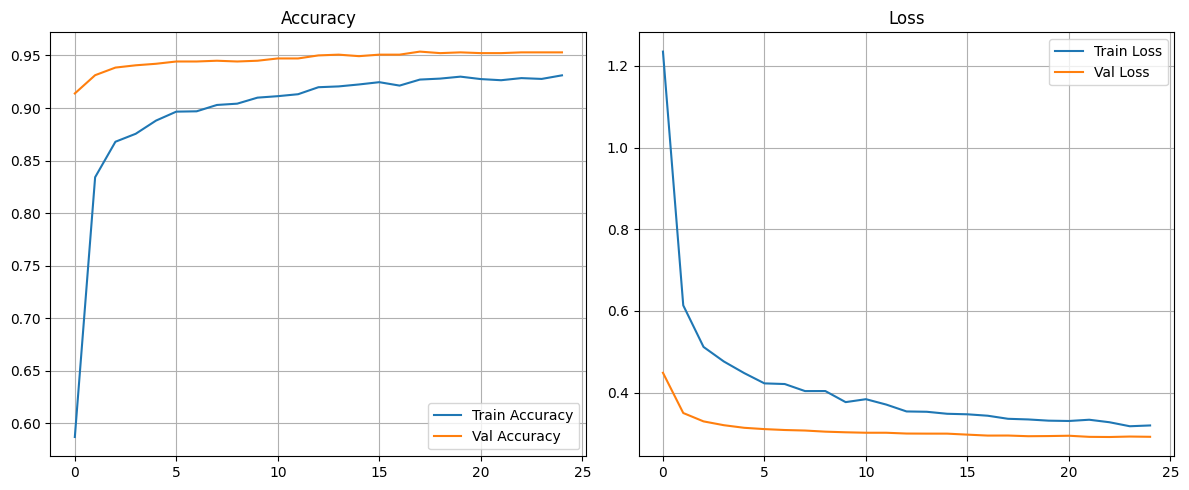


── Evaluación en Test ──
87/87 ━━━━━━━━━━━━━━━━━━━━ 242s 3s/step - accuracy: 0.9525 - f1_score: 0.9524 - loss: 0.2929
  loss: 0.2929
  compile_metrics: 0.9525


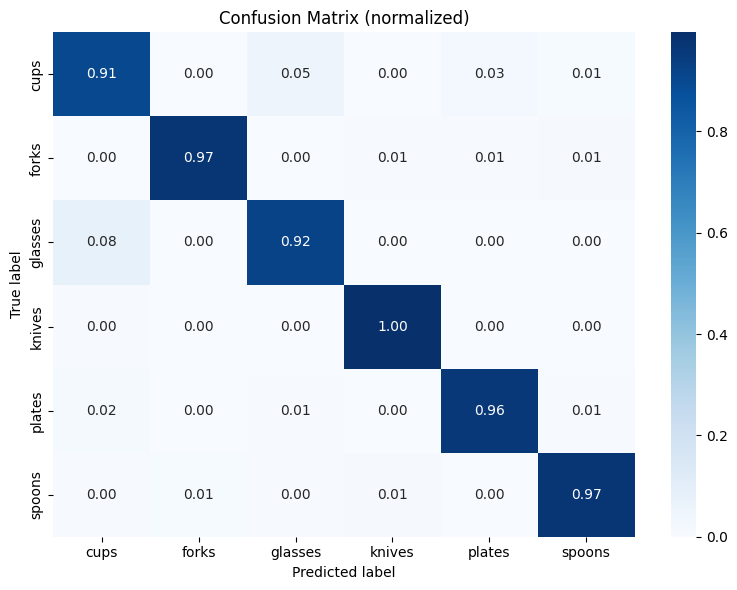

Total mal clasificadas: 66 / 1390


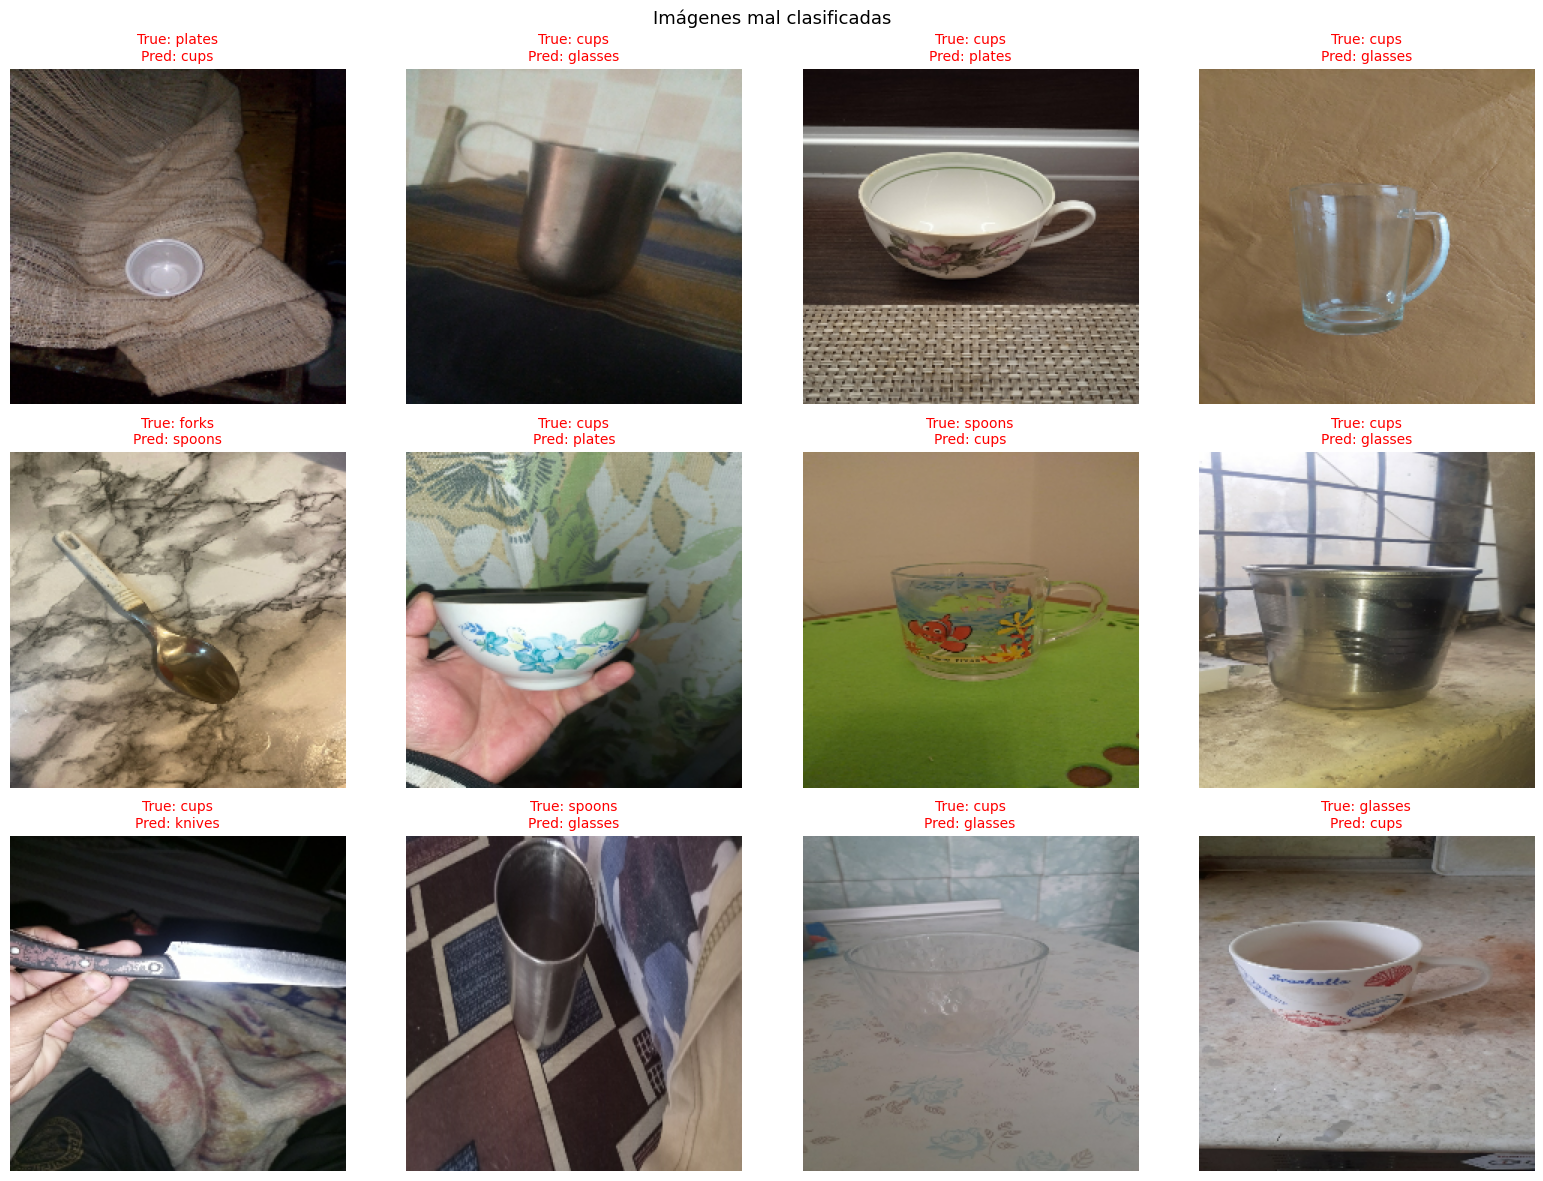

In [16]:
clf = ViTClassifier(num_classes=num_classes)
clf.compile()
clf.fit_model()

clf.plots()
clf.evaluate()

y_true, y_pred, images = clf.get_predictions(test_ds)
clf.plot_confusion_matrix(y_true, y_pred)
clf.plot_misclassified(y_true, y_pred, images)